### Este es un ejercicio para participacion del 19 de marzo

### Parte de este codigo esta reusado de un ejemplo de la clase del 5 de febrero. Esto para la parte de EDA y esas cosas que no se evaluan en la actividad

In [18]:
import pandas as pd
import numpy as np  
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset

import matplotlib.pyplot as plt

In [19]:
# Definir el CUDA antes que nada 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [20]:
x,y = fetch_california_housing(return_X_y=True, as_frame=True)

In [21]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [22]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [23]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


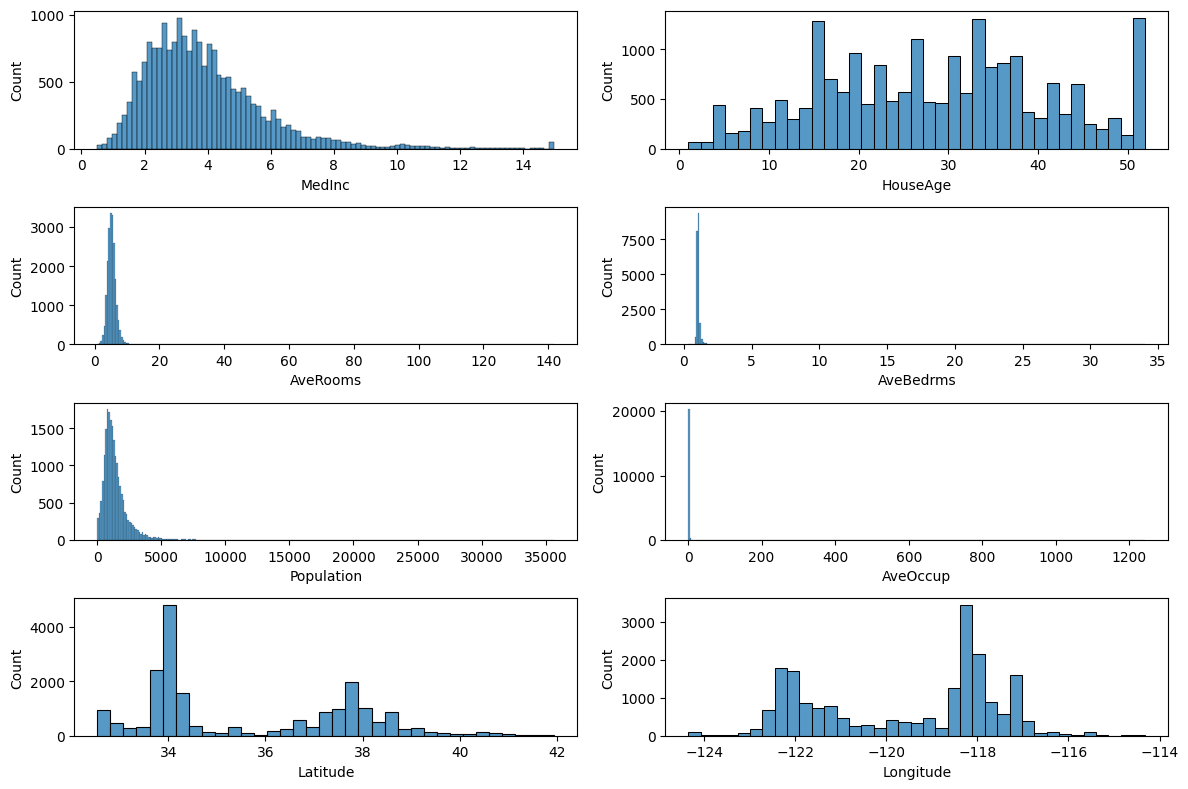

In [24]:
fig, ax = plt.subplots(4,2, figsize=(12,8))

for ax, col in zip(ax.ravel(), x.columns):
    sns.histplot(x[col], ax=ax)

fig.tight_layout()

# VISIBLES Outliers jaja

### Vamos a generar la particion 80/10/10 como menciona en la actividad con la funcion train_test-split de sklearn

In [25]:
from sklearn.model_selection import train_test_split

x_train, x_testval, y_train, y_testval = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_testval,y_testval, test_size=0.5, random_state=42)

pasar estos mismos valores a tensores

In [26]:
# Ya tenemos particionado el dataset pero aun asi tenemos que pasar a tensores para poder usarlos en pytorch y en la red neuronal

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
x_val_tensor   = torch.tensor(x_val.values, dtype=torch.float32)
x_test_tensor  = torch.tensor(x_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

De una vez hacemos los data loaders ya que los vamos a usar para el entrenamiento

In [27]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(x_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Vamos a remover los outliers Utilizando **IQR** pero tenemos que hacerlo con PYTORCH para incluirlo en el mismo pipeline y que ONNX pueda jalar todo junto con el preprocesamiento, al principio pensaba cual sera el uso de esto si puedes hacerlo tu antes de pasarselo a la red neuronal, pero me di cuenta que esto puede ser mas enfocado a la industria y operaciones y pues tener el preprocesamiento en el modelo es clave a la hora de hacer inferencia porque el usuario no se va a poner a escalar datos y remover outliers jajaja

In [28]:
feature_names = [
    "Latitude", "MedInc", "HouseAge", "Longitude",
    "AveRooms", "AveBedrms", "Population", "AveOccup"
]


# Estaba haciendo estas definiciones de manera manual, pero cuando vengan lat y lon en una posicino que no sea 7 y 8 como yo los tenia
# entonces voy a descartar una variable que si quiero transformar y voy a transformar lat o lon
lat_idx = feature_names.index("Latitude")
lon_idx = feature_names.index("Longitude")

# Mejor sacar processs_idx de manera automatica
process_idx = [i for i in range(len(feature_names)) if i not in [lat_idx, lon_idx]] 

Crear los Q1 y Q3 y el IQR que se usara en la red neuronal, necesitamos calcularlo una sola vez en el dataset de train para evitar data leakage y ya esos son los valores que se usaran en la inferencia

In [29]:
x_train_proc = x_train_tensor[:, process_idx]

Q1 = torch.quantile(x_train_proc, 0.25, dim=0)
Q3 = torch.quantile(x_train_proc, 0.75, dim=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# clipping sobre train para calcular mean/std despues del cap
x_train_capped_proc = torch.clamp(x_train_proc, min=lower_bound, max=upper_bound)

mean = x_train_capped_proc.mean(dim=0)
std = x_train_capped_proc.std(dim=0)

Definir la layer de preprocesamiento

In [30]:
class PreprocessingLayer(nn.Module):
    def __init__(self, lower_bound, upper_bound, mean, std, process_idx): # Pasamos como parametros no entrenables lo que calculamos arriba, lo metemos al buffer
        super().__init__()
        self.register_buffer("lower_bound", lower_bound)
        self.register_buffer("upper_bound", upper_bound)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
        self.process_idx = process_idx

    def forward(self, X):
        X_out = X.clone()
        X_proc = X[:, self.process_idx] # Solo quitamos outliers y escalamos en las features fuera de lon y lat
        
        X_proc = torch.clamp(X_proc, min=self.lower_bound, max=self.upper_bound) # Aplicamos clamping de torch por los iqr
        X_proc = (X_proc - self.mean) / (self.std + 1e-8) # Escalamos
        
        X_out[:, self.process_idx] = X_proc # Ahora si regresamos todo el tensor
        return X_out

Definier el modelo

In [ ]:
model1 = nn.Sequential(
    PreprocessingLayer(           # Aqui estamos calleando la preprocessing layer en la red neuronal
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        mean=mean,
        std=std,
        process_idx=process_idx
        
    ),
    nn.Linear(8, 150),
    nn.ReLU(),
    nn.Linear(150, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50, 25),
    nn.ReLU(),
    nn.Linear(25, 1) # Problema de regresion
    ).to(device)

loss = nn.MSELoss()  # MSELoss ya que es un problema de regresion
optimizer = optim.Adam(
    params= model1.parameters(),
    lr=0.005 
)
epochs = 50
batch_size= 64

In [32]:
from tqdm import tqdm 
import numpy as np

def RMSE(y, ytrue):
    rmse = torch.sqrt(torch.mean((y - ytrue) ** 2))
    return rmse

def train_function(train_loader,val_loader, optimizer,loss_fn, epochs,model, device): # ahora hasta paso el device jaja por el CUDA
    epoch_train_loss = []
    epoch_val_loss = []
    epoch_train_RMSE = []
    epoch_val_RMSE = []
    best_val_RMSE = float("inf")
    

    for epoch in range(epochs):
        model.train()    # modo entrenamiento
        train_losses = []
        train_rmses = []
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            optimizer.zero_grad() # Reiniciamos los gradientes de error ya que en cada batch se reinician y se actualizan pesos

            X_batch = X_batch.to(device) # Estos solo los agregue porque me salio un error de que el xbatch y el modelo estaban en diferentes lados
            y_batch = y_batch.to(device) # Uno en CPU y el otro en GPU jaja no entiendo porque si no lo habia usado antes y no tenia problema pero bueno

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            rmse = RMSE(pred, y_batch) 

            loss.backward()   # Calculamos el error distribuido en capas a traves de la red neuronal
            optimizer.step() # Actualizamos los pesos

            train_losses.append(loss.item())
            train_rmses.append(rmse.item())

        epoch_train_loss.append(np.mean(train_losses))
        epoch_train_RMSE.append(np.mean(train_rmses))


        model.eval()
        val_losses = []
        val_rmses = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device) # Same que arriba
                y_val = y_val.to(device)

                val_pred = model(X_val)
                val_loss = loss_fn(val_pred, y_val)
                val_rmse = RMSE(val_pred, y_val) 
                val_losses.append(val_loss.item())
                val_rmses.append(val_rmse.item())

        epoch_val_loss.append(np.mean(val_losses))
        epoch_val_RMSE.append(np.mean(val_rmses))

        print(f"epoch {epoch+1} loss: {epoch_train_loss[-1]:.2f} (train) | {epoch_val_loss[-1]:.2f} (val) , RMSE: {epoch_train_RMSE[-1]:.2f} (train) | {epoch_val_RMSE[-1]:.2f} (val)")
        
        if epoch_val_RMSE[-1] < best_val_RMSE:
            best_val_RMSE = epoch_val_RMSE[-1]
            print(f"Epoch {epoch+1} guardado, hasta ahorita es el mejor")

    return epoch_train_loss, epoch_val_loss, epoch_train_RMSE, epoch_val_RMSE


In [34]:
# llamamos la funcion que acabamos de crear

model1epoch_train_loss, model1epoch_val_loss, model1epoch_train_RMSE, model1epoch_val_RMSE = train_function(
    train_loader, 
    val_loader, 
    optimizer,
    loss, 
    epochs, 
    model1,
    device
    )

Epoch 1/50: 100%|██████████| 258/258 [00:00<00:00, 505.72it/s]


epoch 1 loss: 0.22 (train) | 0.30 (val) , RMSE: 0.46 (train) | 0.54 (val)
Epoch 1 guardado, hasta ahorita es el mejor


Epoch 2/50: 100%|██████████| 258/258 [00:00<00:00, 523.51it/s]


epoch 2 loss: 0.22 (train) | 0.31 (val) , RMSE: 0.46 (train) | 0.54 (val)


Epoch 3/50: 100%|██████████| 258/258 [00:00<00:00, 558.33it/s]


...

epoch 48 loss: 0.18 (train) | 0.30 (val) , RMSE: 0.42 (train) | 0.54 (val)


Epoch 49/50: 100%|██████████| 258/258 [00:00<00:00, 510.13it/s]


epoch 49 loss: 0.18 (train) | 0.32 (val) , RMSE: 0.42 (train) | 0.55 (val)


Epoch 50/50: 100%|██████████| 258/258 [00:00<00:00, 510.65it/s]


epoch 50 loss: 0.18 (train) | 0.30 (val) , RMSE: 0.42 (train) | 0.54 (val)


In [37]:
# Ploteamos las curvas de loss

def plot_loss_curves(train_losses, val_losses):
    #Ok yo estaba pasando num_epochs crudo y eso me dio error varias veces, tengo que construir la lista con range como el ejemplo de la diapositiva
    epochs_updated = range(1, len(train_losses)+1 )

    plt.plot(epochs_updated,train_losses, label="Curva de perdida del entrenamiento")
    plt.plot(epochs_updated,val_losses, label="Curva de perdida en validacion")
    plt.xlabel("Epoch")
    plt.ylabel("Perdida")
    plt.title("Curvas de perdida")
    plt.legend()
    plt.show()

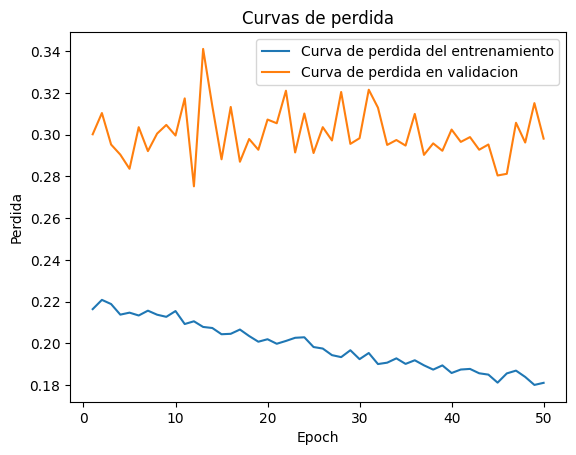

In [38]:
plot_loss_curves(model1epoch_train_loss, model1epoch_val_loss)

In [ ]:
# Ploteamos las curvas de accuracy

def plot_rmse_curves(train_rmses, val_rmses):
    #Ok yo estaba pasando num_epochs crudo y eso me dio error varias veces, tengo que construir la lista con range como el ejemplo de la diapositiva
    epochs_updated = range(1, len(train_rmses)+1 )

    plt.plot(epochs_updated,train_rmses, label="Curva de RMSE del entrenamiento")
    plt.plot(epochs_updated,val_rmses, label="Curva de RMSE en validacion")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("Curvas de RMSE")
    plt.legend()
    plt.show()

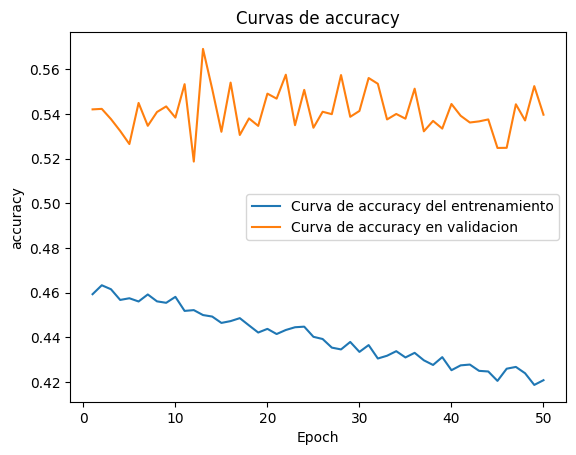

In [40]:
plot_rmse_curves(model1epoch_train_RMSE, model1epoch_val_RMSE)

In [36]:
test_loss_sum = 0.0
test_mse_sum = 0.0

model1.eval()
with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        test_outputs = model1(X_test)

        batch_loss = loss(test_outputs, y_test)
        batch_mse = torch.mean((test_outputs - y_test) ** 2)

        test_loss_sum += batch_loss.item() * X_test.size(0)
        test_mse_sum += batch_mse.item() * X_test.size(0)

test_loss = test_loss_sum / len(test_loader.dataset)
test_RMSE = (test_mse_sum / len(test_loader.dataset)) ** 0.5

print(f"Test Loss: {test_loss:.4f}")
print(f"Test RMSE: {test_RMSE:.4f}")

Test Loss: 0.2749
Test RMSE: 0.5243


### **Definimos los otros 2 modelos**

**modelo 2:**

In [ ]:
model2 = nn.Sequential(
    PreprocessingLayer(           # Aqui estamos calleando la preprocessing layer en la red neuronal
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        mean=mean,
        std=std,
        process_idx=process_idx
        
    ),
    nn.Linear(8, 20),
    nn.ReLU(),
    nn.Linear(20, 10),
    nn.ReLU(),
    nn.Linear(10, 1) # Problema de regresion
    ).to(device)

loss = nn.MSELoss()  # MSELoss ya que es un problema de regresion
optimizer = optim.Adam(
    params= model1.parameters(),
    lr=0.01
)
epochs = 50
batch_size= 64

In [ ]:
model2epoch_train_loss, model2epoch_val_loss, model2epoch_train_RMSE, model2epoch_val_RMSE = train_function(
    train_loader, 
    val_loader, 
    optimizer,
    loss, 
    epochs, 
    model2,
    device
    )

Epoch 1/50: 100%|██████████| 258/258 [00:00<00:00, 518.42it/s]


epoch 1 loss: 5.06 (train) | 5.09 (val) , RMSE: 2.24 (train) | 2.25 (val)
Epoch 1 guardado, hasta ahorita es el mejor


Epoch 2/50: 100%|██████████| 258/258 [00:00<00:00, 615.84it/s]


epoch 2 loss: 5.06 (train) | 5.09 (val) , RMSE: 2.24 (train) | 2.25 (val)


Epoch 3/50: 100%|██████████| 258/258 [00:00<00:00, 662.44it/s]


...

epoch 48 loss: 5.06 (train) | 5.09 (val) , RMSE: 2.24 (train) | 2.25 (val)


Epoch 49/50: 100%|██████████| 258/258 [00:00<00:00, 661.01it/s]


epoch 49 loss: 5.06 (train) | 5.09 (val) , RMSE: 2.24 (train) | 2.25 (val)


Epoch 50/50: 100%|██████████| 258/258 [00:00<00:00, 710.40it/s]

epoch 50 loss: 5.06 (train) | 5.09 (val) , RMSE: 2.24 (train) | 2.25 (val)


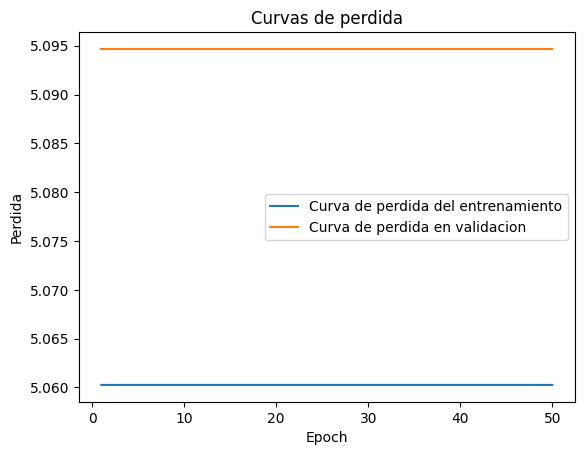

In [43]:
plot_loss_curves(model2epoch_train_loss, model2epoch_val_loss)

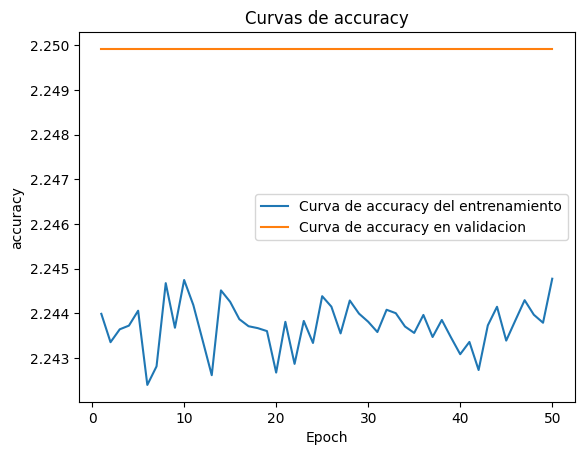

In [44]:
plot_rmse_curves(model2epoch_train_RMSE, model2epoch_val_RMSE)

**modelo 3:**

In [45]:
model3 = nn.Sequential(
    PreprocessingLayer(           # Aqui estamos calleando la preprocessing layer en la red neuronal
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        mean=mean,
        std=std,
        process_idx=process_idx
        
    ),
    nn.Linear(8, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 1) # Problema de regresion
    ).to(device)

loss = nn.MSELoss()  # MSELoss ya que es un problema de regresion
optimizer = optim.Adam(
    params= model1.parameters(),
    lr=0.01 
)
epochs = 50
batch_size= 64

In [ ]:
model3epoch_train_loss, model3epoch_val_loss, model3epoch_train_RMSE, model3epoch_val_RMSE = train_function(
    train_loader, 
    val_loader, 
    optimizer,
    loss, 
    epochs, 
    model.,
    device
    )

In [ ]:
plot_loss_curves(model3epoch_train_loss, model3epoch_val_loss)

In [ ]:
plot_rmse_curves(model3epoch_train_RMSE, model3epoch_val_RMSE)